In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [20]:
# Load the dataset
df = pd.read_excel('Online Retail.xlsx')
print("Data shape", df.shape)
print(df.head())

Data shape (541909, 8)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [21]:
# Remove missing values
df = df.dropna()

# Remove invalid values
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

print(df.shape)

(397884, 8)


In [22]:
# Sales = Quantity * UnitPrice
df['sales'] = df['Quantity'] * df['UnitPrice']

df[['Quantity','UnitPrice','sales']].head()

,Quantity,UnitPrice,sales
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [23]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['month'] = df['InvoiceDate'].dt.month
df['hour'] = df['InvoiceDate'].dt.hour
df['weekday'] = df['InvoiceDate'].dt.weekday
# Chỉnh sửa trong cell tạo đặc trưng thời gian
def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    if month in [3, 4, 5]: return 'Spring'
    if month in [6, 7, 8]: return 'Summer'
    return 'Fall'


In [24]:
le = LabelEncoder()

df['Country'] = df['Country'].astype(str)
df['Country'] = le.fit_transform(df['Country'])

df['StockCode'] = df['StockCode'].astype(str)
df['StockCode'] = le.fit_transform(df['StockCode'])

df['season'] = df['month'].apply(get_season)
df['season'] = le.fit_transform(df['season'])

In [25]:
df['total_spent'] = df.groupby('CustomerID')['sales'].transform('sum')
df['purchase_freq'] = df.groupby('CustomerID')['InvoiceNo'].transform('count')

In [26]:
df['product_popularity'] = df.groupby('StockCode')['Quantity'].transform('sum')

In [34]:
X = df[[
    'Quantity',
    'UnitPrice',
    'Country',
    'month',
    'hour',
    'weekday',
    'season',
    'total_spent',
    'purchase_freq',
    'product_popularity'
]]

y = df['sales']

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

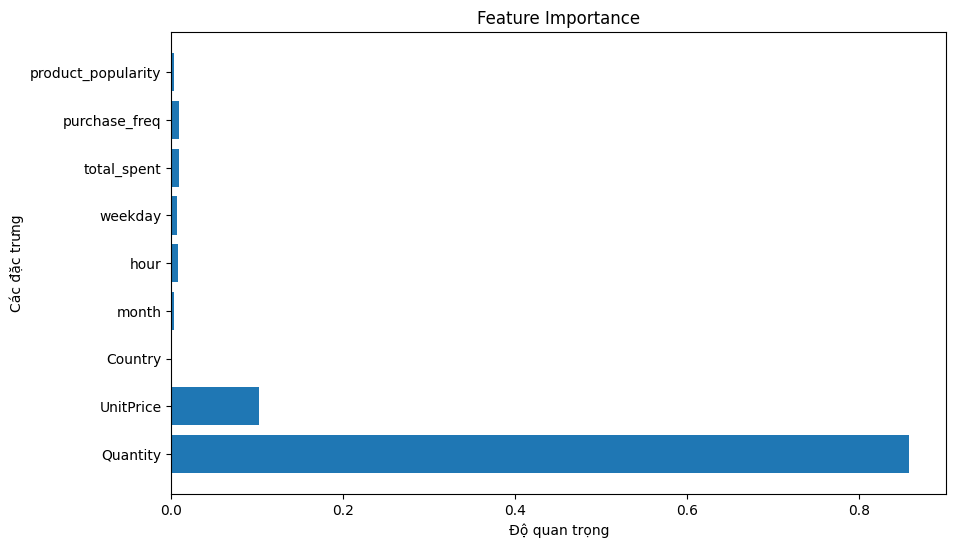

In [35]:

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)
model.fit(X_train, y_train)

importances = model.feature_importances_

plt.figure(figsize=(10, 6))
plt.barh(X_train.columns, importances) 
plt.title("Feature Importance")
plt.xlabel("Độ quan trọng")
plt.ylabel("Các đặc trưng")
plt.show()

In [36]:
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")

MAE: 3.08990200927524
MSE: 163.7624177677374
RMSE: 12.796969085206754


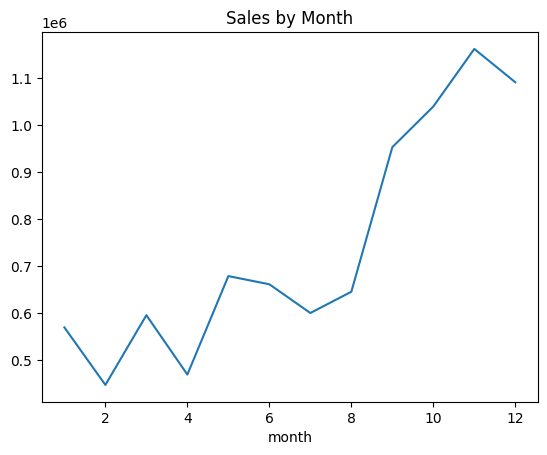

In [31]:
plt.figure()
df.groupby('month')['sales'].sum().plot()
plt.title("Sales by Month")
plt.show()